# GFDL-ESM4 — MLR: FWI vs. 4 Climate Drivers (Thailand)

**Sections 1–5** (dependencies, configuration, data loading, area weights, helpers)
are taken directly from `GFDL-ESM4_FWI_4drivers.ipynb`.  
**Sections 6–10** contain the Multiple Linear Regression analysis.

| Variable | Units (raw) | Grid |
|---|---|---|
| `fwisa` | dimensionless | 0.25° × 0.25° (annual) |
| `tasmax` | K | ~1° × 1° (monthly) |
| `pr` | kg m⁻² s⁻¹ | ~1° × 1° (monthly) |
| `sfcWind` | m s⁻¹ | ~1° × 1° (monthly) |
| `hurs` | % | ~1° × 1° (monthly) |

> Set `DATA_ROOT` in **Section 2** to your local data directory.

## 1  Dependencies

In [40]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2  Configuration

Edit `DATA_ROOT` to match your local data directory, then run all cells.


In [5]:
# ── User configuration ───────────────────────────────────────────────────────
DATA_ROOT = Path("/Volumes/jubjang/Jubjang")   # <-- change this if needed

OUTPUT_FILE = "FWI_vs_4drivers_Thailand_2x2.png"

# Study region: Thailand
TH_SLICE = dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Scenario identifiers
SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

# Display labels (used in legend)
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp585":     "SSP5-8.5",
}

# Colour-blind-friendly palette (Wong, 2011)
PALETTE = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp585":     "#CC79A7",
}


## 3  Load datasets

All variables are loaded lazily with `xarray.open_mfdataset`; actual data are
read on demand during the analysis step.

| Variable | Units (raw) | Grid |
|---|---|---|
| `fwisa` | dimensionless | 0.25° × 0.25° (annual) |
| `tasmax` | K | ~1° × 1° (monthly) |
| `pr` | kg m⁻² s⁻¹ | ~1° × 1° (monthly) |
| `sfcWind` | m s⁻¹ | ~1° × 1° (monthly) |
| `hurs` | % | ~1° × 1° (monthly) |


In [7]:
def _open(path_pattern):
    """
    Open one or more NetCDF files as a single dataset.

    Accepts a single Path/string (with or without ``*`` glob),
    or a list of Paths/strings.  Glob patterns are expanded with
    ``sorted()`` so the time axis is always in chronological order.
    """
    import glob as _glob

    patterns = path_pattern if isinstance(path_pattern, list) else [path_pattern]

    resolved = []
    for p in patterns:
        p_str = str(p)
        if "*" in p_str or "?" in p_str:
            matched = sorted(_glob.glob(p_str))
            if not matched:
                raise FileNotFoundError(
                    f"No files matched the pattern: {p_str}"
                )
            resolved.extend(matched)
        else:
            resolved.append(p_str)

    return xr.open_mfdataset(
        resolved,
        combine="by_coords",
        engine="netcdf4",
    )


# ── FWI (annual, 0.25° grid) ─────────────────────────────────────────────────
FWI_DIR = DATA_ROOT / "FWICMIP6"

fwi_files = {
    "historical": FWI_DIR / "fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc",
    "ssp119":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc",
    "ssp126":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc",
    "ssp245":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc",
    "ssp370":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc",
    "ssp585":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc",
}

# ── tasmax (monthly, ~1° grid) ───────────────────────────────────────────────
TAS_DIR = DATA_ROOT / "tasmax"

tasmax_files = {
    "historical": [
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_201501-210012.nc",
    "ssp126": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── pr (monthly, ~1° grid) ───────────────────────────────────────────────────
PR_DIR = DATA_ROOT / "pr"

pr_files = {
    "historical": [
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": PR_DIR / "pr_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": PR_DIR / "pr_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": PR_DIR / "pr_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": PR_DIR / "pr_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": PR_DIR / "pr_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── sfcWind (monthly, ~1° grid) ──────────────────────────────────────────────
WIND_DIR = DATA_ROOT / "sfcWind"

sfcwind_files = {
    "historical": [
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── hurs (monthly, ~1° grid) ─────────────────────────────────────────────────
HURS_DIR = DATA_ROOT / "hurs"

hurs_files = {
    "historical": [
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_fwi    = {s: _open(fwi_files[s])     for s in SCENARIOS}
ds_tasmax = {s: _open(tasmax_files[s])  for s in SCENARIOS}
ds_pr     = {s: _open(pr_files[s])      for s in SCENARIOS}
ds_wind   = {s: _open(sfcwind_files[s]) for s in SCENARIOS}
ds_hurs   = {s: _open(hurs_files[s])    for s in SCENARIOS}

print("All datasets opened successfully.")


All datasets opened successfully.


## 4  Compute grid-cell area weights

Grid-cell areas are derived analytically from the spherical Earth formula:

$$A_i = R^2 \, \Delta\lambda \, \bigl(\sin\phi_2 - \sin\phi_1\bigr)$$

where $R$ is the Earth's mean radius, $\Delta\lambda$ the longitude spacing,
and $\phi_1, \phi_2$ the latitude bounds of each cell.

Two area grids are constructed because the FWI and driver variables live on
different horizontal resolutions:

| Grid | Shape | Used for |
|---|---|---|
| `areacella` | 72 × 144 | FWI (0.25° native, regridded to 2.5°) |
| `areacella_tas` | 180 × 288 | tasmax / pr / sfcWind / hurs |


In [9]:
def _compute_areacella(lat_coords: np.ndarray, lon_coords: np.ndarray) -> xr.Dataset:
    """
    Return an xr.Dataset with variable ``area`` (km²) on the supplied lat/lon grid.

    Parameters
    ----------
    lat_coords : 1-D array of latitude centres (degrees)
    lon_coords : 1-D array of longitude centres (degrees)
    """
    R = 6_378_137.0  # WGS-84 mean radius (m)

    lat_rad = np.radians(lat_coords)
    lon_rad = np.radians(lon_coords)
    d_lon   = np.diff(lon_rad).mean()
    d_lat   = np.diff(lat_rad).mean()

    area = np.zeros((len(lat_rad), len(lon_rad)))
    for i, phi in enumerate(lat_rad):
        phi1 = phi - d_lat / 2
        phi2 = phi + d_lat / 2
        area[i, :] = R**2 * d_lon * (np.sin(phi2) - np.sin(phi1))

    area_km2 = area / 1e6  # convert m² → km²

    return xr.Dataset({
        "area": xr.DataArray(
            area_km2, dims=["lat", "lon"],
            coords={"lat": lat_coords, "lon": lon_coords},
            attrs={"units": "km2", "long_name": "grid-cell area"},
        )
    })


# FWI grid  (72 lat × 144 lon)
areacella = _compute_areacella(
    lat_coords=np.linspace(-88.75,  88.75,  72),
    lon_coords=np.linspace(  1.25, 358.75, 144),
)

# Driver grid  (180 lat × 288 lon)
areacella_tas = _compute_areacella(
    lat_coords=np.linspace(-89.5,  89.5,  180),
    lon_coords=np.linspace(0.625, 359.375, 288),
)

print("areacella      →", areacella)
print("areacella_tas  →", areacella_tas)


areacella      → <xarray.Dataset>
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03
areacella_tas  → <xarray.Dataset>
Dimensions:  (lat: 180, lon: 288)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4
Data variables:
    area     (lat, lon) float64 135.2 135.2 135.2 135.2 ... 135.2 135.2 135.2


## 5  Analysis helper functions


In [11]:
def _drop_time_dim(da: xr.Dataset) -> xr.Dataset:
    """Remove the time dimension from an area Dataset if present (e.g. after loading)."""
    if "time" in da.dims:
        da = da.isel(time=0)
        da = da.drop_vars([v for v in da.coords if "time" in v], errors="ignore")
    return da


def _annual_mean(ds: xr.Dataset) -> xr.Dataset:
    """Resample monthly data to annual means (calendar-year end)."""
    return ds.resample(time="YS").mean()


def _area_weighted_mean(da: xr.DataArray, weights: xr.Dataset,
                        region: dict) -> xr.DataArray:
    """
    Return the area-weighted spatial mean of *da* over *region*.

    Parameters
    ----------
    da      : DataArray to average (must have lat/lon dims)
    weights : Dataset with an ``area`` variable on a compatible grid
    region  : dict of slice kwargs, e.g. ``dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))``
    """
    w = (
        weights
        .sel(lat=da.lat, lon=da.lon, method="nearest")
        .sel(**region)["area"]
    )
    return da.sel(**region).weighted(w).mean(dim=["lat", "lon"])


## 6. Prepare Thailand Annual Panel DataFrame

Slices Thailand (lat 5.5–20.5°N, lon 97.5–105.5°E), resamples to annual means,
applies area-weighted spatial averaging, and converts units:
- `tasmax`: K → °C
- `pr`: kg m⁻² s⁻¹ → mm day⁻¹

Output columns: `time`, `scenario`, `FWI`, `tasmax`, `pr`, `hurs`, `sfcWind`

In [17]:
def prepare_panel_th_for_plots_and_mlr(
    datasets_fwi, datasets_tasmax, datasets_pr, datasets_hurs, datasets_sfcWind,
    labels, areacella_fwi, areacella_tas,
    lat_bounds=(5.5, 20.5), lon_bounds=(97.5, 105.5),
    fwi_is_yearly=True
):
    """
    Build a tidy annual panel DataFrame for Thailand for use in MLR.

    Parameters
    ----------
    datasets_fwi / tasmax / pr / hurs / sfcWind : lists of xarray.Dataset
        One dataset per scenario, in the same order as `labels`.
    labels : list[str]
        Scenario labels (e.g. 'Historical', 'SSP1-1.9', …).
    areacella_fwi : xarray.Dataset
        Area weights that match the FWI / pr / hurs / sfcWind grid.
    areacella_tas : xarray.Dataset
        Area weights that match the tasmax grid.
    lat_bounds, lon_bounds : tuple
        Geographic bounding box for Thailand.
    fwi_is_yearly : bool
        True if FWI data are already annual (no resampling needed).

    Returns
    -------
    panel_df : pd.DataFrame
        Columns: time (int year), scenario, FWI, tasmax (°C),
                 pr (mm/day), hurs (%), sfcWind (m/s)
    """
    lat_slice = slice(*lat_bounds)
    lon_slice = slice(*lon_bounds)

    # Remove time dimension from area weights if present, then slice to Thailand
    area_fwi = areacella_fwi
    if 'time' in area_fwi.dims:
        area_fwi = area_fwi.isel(time=0)
    area_fwi = area_fwi['area'].sel(lat=lat_slice, lon=lon_slice)

    area_tas = areacella_tas
    if 'time' in area_tas.dims:
        area_tas = area_tas.isel(time=0)
    area_tas = area_tas['area'].sel(lat=lat_slice, lon=lon_slice)

    rows = []

    for ds_fwi, ds_tas, ds_pr, ds_hurs, ds_wind, label in zip(
        datasets_fwi, datasets_tasmax, datasets_pr, datasets_hurs, datasets_sfcWind, labels
    ):
        # 1) Slice to Thailand
        fwi_th  = ds_fwi .sel(lat=lat_slice, lon=lon_slice)
        tas_th  = ds_tas .sel(lat=lat_slice, lon=lon_slice)
        pr_th   = ds_pr  .sel(lat=lat_slice, lon=lon_slice)
        hurs_th = ds_hurs.sel(lat=lat_slice, lon=lon_slice)
        wind_th = ds_wind.sel(lat=lat_slice, lon=lon_slice)

        # 2) Extract variables
        fwi_da  = fwi_th ['fwisa']   # dimensionless, already annual
        tas_da  = tas_th ['tasmax']  # K, monthly
        pr_da   = pr_th  ['pr']      # kg m-2 s-1, monthly
        hurs_da = hurs_th['hurs']    # %, monthly
        wind_da = wind_th['sfcWind'] # m/s, monthly

        # 3) Resample to annual
        fwi_y   = fwi_da  if fwi_is_yearly else fwi_da.resample(time='YS').mean()
        tas_y   = tas_da  .resample(time='YS').mean()
        pr_y    = pr_da   .resample(time='YS').mean()
        hurs_y  = hurs_da .resample(time='YS').mean()
        wind_y  = wind_da .resample(time='YS').mean()

        # 4) Align all variables to the FWI time axis of this scenario
        tas_y  = tas_y .sel(time=fwi_y['time'], method='nearest')
        pr_y   = pr_y  .sel(time=fwi_y['time'], method='nearest')
        hurs_y = hurs_y.sel(time=fwi_y['time'], method='nearest')
        wind_y = wind_y.sel(time=fwi_y['time'], method='nearest')

        # 5) Area-weighted spatial mean
        fwi_mean  = fwi_y .weighted(area_fwi).mean(dim=['lat', 'lon'])
        tas_mean  = tas_y .weighted(area_tas).mean(dim=['lat', 'lon'])
        pr_mean   = pr_y  .weighted(area_tas).mean(dim=['lat', 'lon'])
        hurs_mean = hurs_y.weighted(area_tas).mean(dim=['lat', 'lon'])
        wind_mean = wind_y.weighted(area_tas).mean(dim=['lat', 'lon'])

        # 6) Unit conversion
        tas_C    = tas_mean - 273.15   # K → °C
        pr_mmday = pr_mean  * 86400.0  # kg m-2 s-1 → mm day-1

        # 7) Collect into a per-scenario DataFrame
        years = fwi_mean.indexes['time'].year
        df = pd.DataFrame({
            'time'    : years.astype(int),
            'FWI'     : fwi_mean.values,
            'tasmax'  : tas_C.values,
            'pr'      : pr_mmday.values,
            'hurs'    : hurs_mean.values,
            'sfcWind' : wind_mean.values,
            'scenario': label,
        })
        rows.append(df)

    panel_df = pd.concat(rows, ignore_index=True)

    # 8) Sanitise: cast to numeric, drop inf/NaN
    for c in ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']:
        panel_df[c] = pd.to_numeric(panel_df[c], errors='coerce')
    panel_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel_df.dropna(subset=['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind'], inplace=True)
    panel_df['time'] = panel_df['time'].astype(int)

    return panel_df


# Convert dict-based datasets (from Section 3) into ordered lists
_scen_order   = SCENARIOS
_labels_list  = [SCENARIO_LABELS[s] for s in _scen_order]
_fwi_list     = [ds_fwi[s]    for s in _scen_order]
_tasmax_list  = [ds_tasmax[s] for s in _scen_order]
_pr_list      = [ds_pr[s]     for s in _scen_order]
_hurs_list    = [ds_hurs[s]   for s in _scen_order]
_sfcWind_list = [ds_wind[s]   for s in _scen_order]

panel_df_th = prepare_panel_th_for_plots_and_mlr(
    _fwi_list, _tasmax_list, _pr_list, _hurs_list, _sfcWind_list,
    _labels_list,
    areacella_fwi=areacella,
    areacella_tas=areacella_tas,
    fwi_is_yearly=True,   # Set False if FWI data are monthly
)

print(panel_df_th.head())
print()
print('Rows per scenario:')
print(panel_df_th.groupby('scenario').size())


   time        FWI     tasmax        pr       hurs   sfcWind    scenario
0  1850  16.446996  27.704424  5.439578  78.241219  2.801015  Historical
1  1851  11.380531  26.799990  6.135823  81.961122  2.766128  Historical
2  1852  25.823938  28.306912  4.368917  75.373456  2.798113  Historical
3  1853  26.306468  28.177829  5.181392  76.485319  2.816172  Historical
4  1854  12.236745  26.849098  5.353400  80.965706  2.773738  Historical

Rows per scenario:
scenario
Historical    165
SSP1-1.9       86
SSP1-2.6       86
SSP2-4.5       86
SSP3-7.0       86
SSP5-8.5       86
dtype: int64


## 7. OLS Multiple Linear Regression

Fits: `FWI ~ tasmax + pr + hurs + sfcWind [+ C(scenario)]`

- HC1 heteroskedasticity-robust standard errors are used.
- Scenario fixed effects are added automatically when ≥ 2 scenarios are present.

In [26]:
assert 'panel_df_th' in globals() and len(panel_df_th) > 0, \
    "panel_df_th is missing or empty — run Section 6 first."

# --- OLS formula (with scenario fixed effects if multi-scenario) ---
use_fe  = panel_df_th['scenario'].nunique() >= 2
formula = 'FWI ~ tasmax + pr + hurs + sfcWind' + (' + C(scenario)' if use_fe else '')
print('Formula:', formula)

# --- Fit with HC1 robust SEs ---
mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print(mlr_model.summary())


Formula: FWI ~ tasmax + pr + hurs + sfcWind + C(scenario)
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     361.6
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          2.12e-232
Time:                        02:43:30   Log-Likelihood:                -1216.4
No. Observations:                 595   AIC:                             2453.
Df Residuals:                     585   BIC:                             2497.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

## 8. Standardised (Beta) Coefficients

All continuous variables are z-scored so coefficients are directly comparable
in units of standard deviations.

In [28]:
# Z-score continuous variables only (not the categorical scenario)
to_z   = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
df_std = panel_df_th.copy()
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')

print('=== Standardised (beta) coefficients ===')
print(mlr_model_beta.params[['tasmax', 'pr', 'hurs', 'sfcWind']])
print()
print('Positive beta => variable increases as FWI increases')
print('Negative beta => inverse relationship with FWI')

# --- Full coefficient table (HC1 SE, t, p, 95% CI) ---
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96 * coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96 * coef_table['HC1_se']
print()
print('=== Coefficients table (HC1) ===')
print(coef_table.round(4))


=== Standardised (beta) coefficients ===
tasmax     0.078116
pr         0.162410
hurs      -0.961896
sfcWind    0.007805
dtype: float64

Positive beta => variable increases as FWI increases
Negative beta => inverse relationship with FWI

=== Coefficients table (HC1) ===
                             coef   HC1_se        t  pvalue    CI_low  \
Intercept                192.5503  10.8186  17.7981  0.0000  171.3459   
C(scenario)[T.SSP1-1.9]   -1.4212   0.2911  -4.8826  0.0000   -1.9917   
C(scenario)[T.SSP1-2.6]   -1.1567   0.3019  -3.8317  0.0001   -1.7484   
C(scenario)[T.SSP2-4.5]   -0.7922   0.3245  -2.4412  0.0146   -1.4283   
C(scenario)[T.SSP3-7.0]    0.1969   0.3849   0.5116  0.6089   -0.5574   
C(scenario)[T.SSP5-8.5]   -1.1723   0.3851  -3.0440  0.0023   -1.9272   
tasmax                     0.3623   0.1587   2.2824  0.0225    0.0512   
pr                         1.7302   0.2509   6.8959  0.0000    1.2384   
hurs                      -2.4628   0.0783 -31.4555  0.0000   -2.6163   

## 9. Diagnostic Plots

Visual checks for model fit quality.

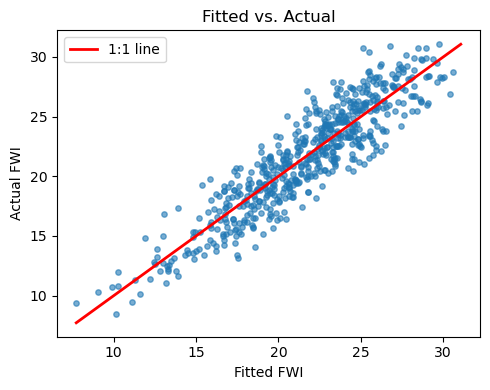

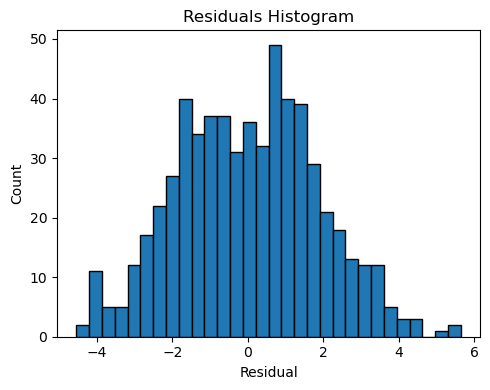

In [31]:
y     = panel_df_th['FWI'].values
yhat  = mlr_model.fittedvalues.values
resid = mlr_model.resid.values

# --- Fitted vs Actual ---
plt.figure(figsize=(5, 4))
plt.scatter(yhat, y, s=15, alpha=0.6)
mn, mx = np.min([y, yhat]), np.max([y, yhat])
plt.plot([mn, mx], [mn, mx], lw=2, color='red', label='1:1 line')
plt.xlabel('Fitted FWI')
plt.ylabel('Actual FWI')
plt.title('Fitted vs. Actual')
plt.legend()
plt.tight_layout()
plt.show()

# --- Residuals histogram ---
plt.figure(figsize=(5, 4))
plt.hist(resid, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residuals Histogram')
plt.tight_layout()
plt.show()


## 10. Variance Inflation Factors (VIF)

VIF > 10 typically indicates problematic multicollinearity.

In [42]:
cols          = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
panel_df_clean = panel_df_th.dropna(subset=cols).copy()

X = panel_df_clean[['tasmax', 'pr', 'hurs', 'sfcWind']]
X = add_constant(X)

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF'     : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print(vif_data.round(2))


  Variable      VIF
0    const  9968.39
1   tasmax     1.62
2       pr     1.46
3     hurs     2.29
4  sfcWind     1.19
